Langkah Ke-1 Inisialisasi Library

In [1]:
import warnings
import os
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from IPython.display import display, Markdown

os.environ['LOKY_MAX_CPU_COUNT'] = '4' 
warnings.filterwarnings("ignore", category=UserWarning)

Langkah Ke-2 Load Dataset + Data Preprocessing (Data Cleansing)

In [12]:
# ── Load Dataset ──────────────────────────────────────────────
df = pd.read_excel('data/1_Data_Raw/Dataset.xlsx')

print("=== INFO AWAL ===")
print(f"Jumlah Baris : {df.shape[0]}")
print(f"Jumlah Variabel : {df.shape[1]}")
print("\n=== MISSING VALUES ===")
print(df.isnull().sum()) # me-return jumlah nilai kosong (missing) untuk setiap kolom.

# ── STEP 1: Fill NA dengan 0 (hanya kolom numerik data) ──────
kolom_numerik = [
    'Jumlah Mahasiswa', 'Jumlah Mahasiswa Asing', 'Jumlah Dosen',
    'Jumlah Dosen Asing', 'Jumlah Dosen S3', 'Jumlah Inbound',
    'Jumlah Outbound', 'Jumlah Artikel di Jurnal Terindeks Scopus',
    'Jumlah Sitasi Per Prodi',
    'Jumlah Artikel yang Melibatkan Kolaborator Internasional',
    'Jumlah Negara Kolaborator', 'Jumlah Institusi Unik'
]

for col in kolom_numerik:
    # Konversi, ubah non-numerik menjadi NaN
    konversi = pd.to_numeric(df[col], errors='coerce')
    # Temukan baris yang menjadi NaN padahal sebelumnya bukan NaN (atau berisi string)
    mask_gagal = konversi.isna() & df[col].notna()  # opsional: df[col] != '' jika ada string kosong
    
    if mask_gagal.any():
        print(f"\nKolom '{col}' memiliki {mask_gagal.sum()} data non-numerik:")
        print(df.loc[mask_gagal, ['Program Studi', col]])

df[kolom_numerik] = df[kolom_numerik].fillna(0) # Buat Mengganti semua nilai NaN (Not a Number) dengan 0.

# ── STEP 2: Pastikan tipe data numerik (antisipasi data terbaca sebagai string) ──
df[kolom_numerik] = df[kolom_numerik].apply(pd.to_numeric, errors='coerce').fillna(0) 
# .apply(pd.to_numeric, errors='coerce') => Semua data diganti jadi numerik, kalo ada yg gabisa dikonversi maka langsung diganti NaN
# .fillna(0) => Buat Mengganti semua nilai NaN (Not a Number) dengan 0.

# ── STEP 3: Identifikasi & hapus baris Mahasiswa = 0 atau Dosen = 0 ──
mask_hapus = (df['Jumlah Mahasiswa'] == 0) | (df['Jumlah Dosen'] == 0)

print(f"\nBARIS YANG DIHAPUS ({mask_hapus.sum()} baris)")
# Sesuaikan kolom identitas dengan nama kolom di dataset Anda
print(df[mask_hapus][['Program Studi', 'Jumlah Mahasiswa', 'Jumlah Dosen']])

df_clean = df[~mask_hapus].reset_index(drop=True)
print(f"\nJumlah baris setelah cleaning: {df_clean.shape[0]}")
print(f"Jumlah variabel setelah cleaning: {df_clean.shape[1]}")
print(f"Jumlah data NaN setelah cleaning: {df_clean.isna().sum()}")

# Simpan hasil cleaning
df_clean.to_excel('data/2_Data_Preprocessed/1_Hasil_Data_Cleansing.xlsx', index=False)
# df_clean.to_excel('data/2_Data_Preprocessed/xlsx/1_Hasil_Data_Cleansing.xlsx', index=False)
# df_clean.to_csv('data/2_Data_Preprocessed/csv/1_Hasil_Data_Cleansing.csv', index=False)

=== INFO AWAL ===
Jumlah Baris : 175
Jumlah Variabel : 13

=== MISSING VALUES ===
Program Studi                                               0
Jumlah Mahasiswa                                            0
Jumlah Mahasiswa Asing                                      0
Jumlah Dosen                                                0
Jumlah Dosen Asing                                          0
Jumlah Dosen S3                                             0
Jumlah Inbound                                              0
Jumlah Outbound                                             0
Jumlah Artikel di Jurnal Terindeks Scopus                   0
Jumlah Sitasi Per Prodi                                     0
Jumlah Artikel yang Melibatkan Kolaborator Internasional    0
Jumlah Negara Kolaborator                                   0
Jumlah Institusi Unik                                       0
dtype: int64

Kolom 'Jumlah Mahasiswa' memiliki 2 data non-numerik:
                                   Program S

In [ ]:
data_hasil_cleansing_xlsx = pd.read_excel('data/2_Data_Preprocessed/xlsx/1_Hasil_Data_Cleansing.xlsx')
data_hasil_cleansing_csv = pd.read_csv('data/2_Data_Preprocessed/csv/1_Hasil_Data_Cleansing.csv')
data_hasil_cleansing_xlsx.head()
# data_hasil_cleansing_csv.head()

Langkah Ke-3 Data Preprocessing (Data Selection)

In [13]:
# ── Drop kolom yang tidak digunakan ──────────────────────────
df_selected = df_clean.drop(
    columns=['Jumlah Artikel yang Melibatkan Kolaborator Internasional']
)

print("=== KOLOM SETELAH SELEKSI ===")
print(df_selected.columns.tolist())

df_selected.to_excel('data/2_Data_Preprocessed/2_Hasil_Data_Selection.xlsx', index=False)
# df_selected.to_excel('data/2_Data_Preprocessed/xlsx/2_Hasil_Data_Selection.xlsx', index=False)
# df_selected.to_csv('data/2_Data_Preprocessed/csv/2_Hasil_Data_Selection.csv', index=False)

=== KOLOM SETELAH SELEKSI ===
['Program Studi', 'Jumlah Mahasiswa', 'Jumlah Mahasiswa Asing', 'Jumlah Dosen', 'Jumlah Dosen Asing', 'Jumlah Dosen S3', 'Jumlah Inbound', 'Jumlah Outbound', 'Jumlah Artikel di Jurnal Terindeks Scopus', 'Jumlah Sitasi Per Prodi', 'Jumlah Negara Kolaborator', 'Jumlah Institusi Unik']


In [ ]:
data_hasil_Selection_xlsx = pd.read_excel('data/2_Data_Preprocessed/xlsx/2_Hasil_Data_Selection.xlsx')
data_hasil_Selection_csv = pd.read_csv('data/2_Data_Preprocessed/csv/2_Hasil_Data_Selection.csv')
data_hasil_Selection_xlsx.head()
# data_hasil_Selection_csv.head()

Langkah Ke-4 Data Preprocessing (Data Transformation)

In [14]:
df_transform = df_selected.copy()

# ── 1. Faculty / Student Ratio (FSR) ─────────────────────────
# Penyebut (Mahasiswa) dijamin > 0 setelah cleaning
df_transform['FSR'] = df_transform['Jumlah Dosen'] / df_transform['Jumlah Mahasiswa']

# ── 2. International Research Network (IRN) ──────────────────
# Penanganan khusus: ln(1) = 0 dan kasus belum kolaborasi
def hitung_irn(row):
    negara   = row['Jumlah Negara Kolaborator']
    institusi = row['Jumlah Institusi Unik']

    # Case 4: Negara=0 & Institusi=0 → belum kolaborasi internasional
    if negara == 0 and institusi == 0:
        return 0.0
    # Case 5: Institusi=1 → ln(1)=0, hindari pembagian nol
    elif institusi <= 1:
        return 0.0
    # Case 1: Normal
    else:
        return negara / np.log(institusi)

df_transform['IRN'] = df_transform.apply(hitung_irn, axis=1)

# ── 3. Citations per Paper (CPP) ─────────────────────────────
# Penanganan khusus: artikel=0 → CPP=0 (termasuk sitasi>0 yg tidak mungkin)
def hitung_cpp(row):
    artikel = row['Jumlah Artikel di Jurnal Terindeks Scopus']
    sitasi  = row['Jumlah Sitasi Per Prodi']

    if artikel == 0:
        # Case 2 (sitasi=0) & Case 3 (sitasi>0, tidak mungkin) → keduanya 0
        return 0.0
    else:
        # Case 1: artikel>0, sitasi bisa 0 (belum disitasi) → hasil tetap 0
        return sitasi / artikel

df_transform['CPP'] = df_transform.apply(hitung_cpp, axis=1)

# ── 4. Papers per Faculty (PPF) ──────────────────────────────
# Penyebut (Dosen) dijamin > 0 setelah cleaning
# Pembilang=0 → PPF=0 secara alami dari pembagian
df_transform['PPF'] = (
    df_transform['Jumlah Artikel di Jurnal Terindeks Scopus'] / df_transform['Jumlah Dosen']
)

# ── 5. Staff with PhD ─────────────────────────────────────────
df_transform['Staff_PhD (%)'] = (
    df_transform['Jumlah Dosen S3'] / df_transform['Jumlah Dosen']
) * 100

# ── 6. International Faculty Ratio ───────────────────────────
df_transform['IFR (%)'] = (
    df_transform['Jumlah Dosen Asing'] / df_transform['Jumlah Dosen']
) * 100

# ── 7. Proportion of International Students ──────────────────
df_transform['PIS (%)'] = (
    df_transform['Jumlah Mahasiswa Asing'] / df_transform['Jumlah Mahasiswa']
) * 100

# ── 8. Proportion of Inbound Exchange Students ───────────────
df_transform['Inbound (%)'] = (
    df_transform['Jumlah Inbound'] / df_transform['Jumlah Mahasiswa']
) * 100

# ── 9. Proportion of Outbound Exchange Students ──────────────
df_transform['Outbound (%)'] = (
    df_transform['Jumlah Outbound'] / df_transform['Jumlah Mahasiswa']
) * 100

# ── Susun kolom output final ──────────────────────────────────
kolom_identitas = ['Program Studi']  # sesuaikan nama kolom Anda
kolom_qs = ['FSR', 'IRN', 'CPP', 'PPF',
            'Staff_PhD (%)', 'IFR (%)', 'PIS (%)', 'Inbound (%)', 'Outbound (%)']

df_final = df_transform[kolom_identitas + kolom_qs]

print("=== PREVIEW HASIL TRANSFORMASI ===")
print(df_final.head())

print("\n=== STATISTIK DESKRIPTIF VARIABEL QS ===")
print(df_final[kolom_qs].describe().round(4))

# Simpan hasil akhir preprocessing
df_final.to_excel('data/2_Data_Preprocessed/3_Hasil_Data_Transformation.xlsx', index=False)
# df_final.to_excel('data/2_Data_Preprocessed/xlsx/3_Hasil_Data_Transformation.xlsx', index=False)
# df_final.to_csv('data/2_Data_Preprocessed/csv/3_Hasil_Data_Transformation.csv', index=False)


=== PREVIEW HASIL TRANSFORMASI ===
                   Program Studi       FSR       IRN       CPP       PPF  \
0       UNEJ - Pendidikan Dokter  0.073913  1.923593  5.927273  3.235294   
1              UNEJ - Ilmu Hukum  0.027595  2.627670  1.600000  0.714286   
2         UNEJ - Ilmu Hukum (S2)  0.017857  0.000000  1.833333  6.000000   
3       UNEJ - Kenotariatan (S2)  0.020921  1.442695  2.257143  7.000000   
4  UNEJ - Pendidikan Dokter Gigi  0.042433  3.728010  4.833333  5.600000   

   Staff_PhD (%)  IFR (%)  PIS (%)  Inbound (%)  Outbound (%)  
0      19.607843      0.0      0.0     0.144928      0.000000  
1      19.047619      0.0      0.0     0.306614      0.043802  
2     100.000000      0.0      0.0     0.000000      0.000000  
3     100.000000      0.0      0.0     0.000000      0.000000  
4      46.666667      0.0      0.0     0.141443      0.000000  

=== STATISTIK DESKRIPTIF VARIABEL QS ===
            FSR       IRN       CPP       PPF  Staff_PhD (%)   IFR (%)  \
count  1

Langkah Ke-5 Cek Outlier Untuk Penentuan Metode Normalisasi

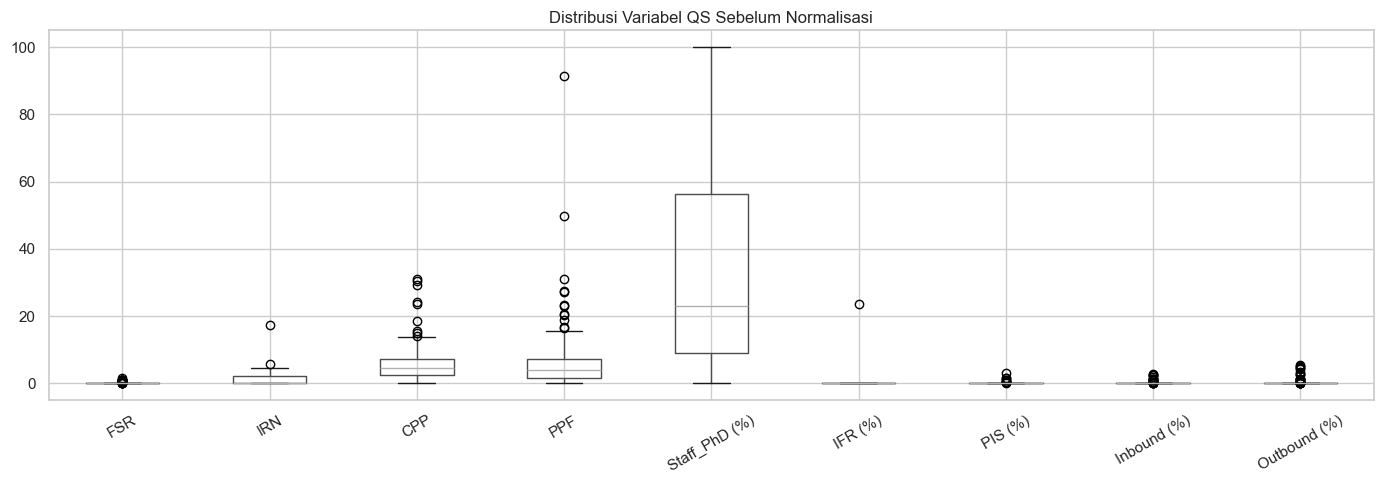

In [14]:
kolom_qs = ['FSR', 'IRN', 'CPP', 'PPF', 'Staff_PhD (%)', 
            'IFR (%)', 'PIS (%)', 'Inbound (%)', 'Outbound (%)']

df_final[kolom_qs].boxplot(figsize=(14, 5), rot=30)
plt.title('Distribusi Variabel QS Sebelum Normalisasi')
plt.tight_layout()
plt.show()

# FSR, IFR, PIS, Inbound, Outbound — Kotak sangat tipis mendekati nol, artinya mayoritas program studi memang bernilai sangat kecil. Wajar untuk universitas regional.
# IRN & CPP — Ada beberapa outlier (titik bulat di atas), tapi masih dalam batas wajar.
# PPF — Ada outlier dari ~50 dan ~90, perlu diwaspadai saat normalisasi Min-Max.
# Staff_PhD (%) — Ini yang paling perlu diperhatikan. Kotak sangat besar (Q1 ≈ 0, Q3 ≈ 55, max = 100). Artinya distribusinya sangat tersebar, ada program studi dengan 0% hingga 100% dosen bergelar doktor.

Langkah ke-6 Data Preprocessing (Normalisasi Menggunakan Z-Score) 

In [17]:
# ── 1. Load Data dari CSV ─────────────────────────────────────
# df = pd.read_csv('data/2_Data_Preprocessed/csv/3_Hasil_Data_Transformation.csv')
df = pd.read_excel('data/2_Data_Preprocessed/3_Hasil_Data_Transformation.xlsx')

print("=== DATA SEBELUM NORMALISASI ===")
print(df.head(3))
print(f"\nShape: {df.shape}")

# ── 2. Definisikan kolom identitas vs kolom yang dinormalisasi ─
kolom_identitas = ['Program Studi']
kolom_qs = [
    'FSR', 'IRN', 'CPP', 'PPF',
    'Staff_PhD (%)', 'IFR (%)', 'PIS (%)',
    'Inbound (%)', 'Outbound (%)'
]

# ── 3. Terapkan Z-Score hanya pada kolom variabel QS ──────────
scaler = StandardScaler()
data_normalized = scaler.fit_transform(df[kolom_qs])

# ── 4. Susun DataFrame hasil normalisasi ──────────────────────
df_normalized = pd.DataFrame(data_normalized, columns=kolom_qs)
df_normalized.insert(0, 'Program Studi', df['Program Studi'].values)

# ── 5. Buat folder normalized jika belum ada ──────────────────
os.makedirs('data/3_Data_Normalized', exist_ok=True)

# ── 6. Simpan ke CSV dan Excel ────────────────────────────────
# output_csv  = 'data/3_Data_Normalized/Hasil_ZScore_Data_Normalization.csv'
output_xlsx = 'data/3_Data_Normalized/Hasil_ZScore_Data_Normalization.xlsx'

# df_normalized.to_csv(output_csv, index=False)
df_normalized.to_excel(output_xlsx, index=False)

# ── 7. Preview hasil ──────────────────────────────────────────
print("\n=== DATA SETELAH NORMALISASI Z-SCORE (5 baris pertama) ===")
print(df_normalized.head())

print("\n=== STATISTIK DESKRIPTIF SETELAH NORMALISASI ===")
print(df_normalized[kolom_qs].describe().round(4))

# ── 8. Verifikasi kebenaran Z-Score ───────────────────────────
# Mean setiap kolom seharusnya ≈ 0
# Std setiap kolom seharusnya ≈ 1
print("\n=== VERIFIKASI HASIL (mean ≈ 0 dan std ≈ 1 = BERHASIL) ===")
verifikasi = pd.DataFrame({
    'Mean'  : df_normalized[kolom_qs].mean().round(6),
    'Std'   : df_normalized[kolom_qs].std().round(6)
})
print(verifikasi)

print(f"\nFile berhasil disimpan:")
# print(f"  → {output_csv}")
print(f"  → {output_xlsx}")

=== DATA SEBELUM NORMALISASI ===
              Program Studi       FSR       IRN       CPP       PPF  \
0  UNEJ - Pendidikan Dokter  0.073913  1.923593  5.927273  3.235294   
1         UNEJ - Ilmu Hukum  0.027595  2.627670  1.600000  0.714286   
2    UNEJ - Ilmu Hukum (S2)  0.017857  0.000000  1.833333  6.000000   

   Staff_PhD (%)  IFR (%)  PIS (%)  Inbound (%)  Outbound (%)  
0      19.607843      0.0      0.0     0.144928      0.000000  
1      19.047619      0.0      0.0     0.306614      0.043802  
2     100.000000      0.0      0.0     0.000000      0.000000  

Shape: (171, 10)

=== DATA SETELAH NORMALISASI Z-SCORE (5 baris pertama) ===
                   Program Studi       FSR       IRN       CPP       PPF  \
0       UNEJ - Pendidikan Dokter -0.192951  0.451346  0.051053 -0.327208   
1              UNEJ - Ilmu Hukum -0.393983  0.845670 -0.790350 -0.599758   
2         UNEJ - Ilmu Hukum (S2) -0.436250 -0.625979 -0.744981 -0.028312   
3       UNEJ - Kenotariatan (S2) -0.422954  

Langkah Ke-7 Pencarian Jumlah Cluster Optimal Menurut Elbow Method dan Silhouette Score

Jumlah data (N) = 171
Rekomendasi K Optimal (Elbow Method)   : 8
Rekomendasi K Optimal (Silhouette Score): 9


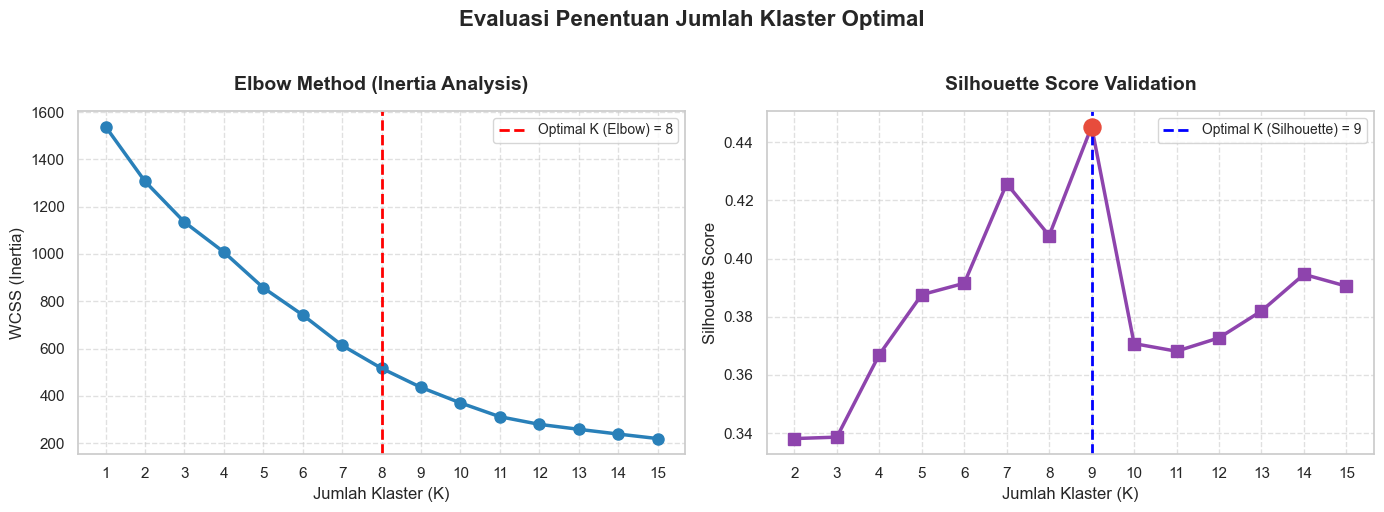

In [18]:
# ── 0. Load Data ──
df_normalized = pd.read_excel('data/3_Data_Normalized/Hasil_ZScore_Data_Normalization.xlsx')
kolom_qs = ['FSR', 'IRN', 'CPP', 'PPF', 'Staff_PhD (%)',
            'IFR (%)', 'PIS (%)', 'Inbound (%)', 'Outbound (%)']
X = df_normalized[kolom_qs].values
N = X.shape[0]
print(f"Jumlah data (N) = {N}")

# ── 1. Perhitungan WCSS & Silhouette untuk Range K ──
max_k = 15
K_range = list(range(1, max_k + 1))
K_range_sil = list(range(2, max_k + 1))  # Silhouette hanya bisa dihitung untuk K >= 2

wcss = []
sil_scores = []

for k in K_range:
    # Set n_init=10 untuk stabilitas inisialisasi centroid
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    wcss.append(kmeans.inertia_)
    
    # Hitung Silhouette Score hanya jika K >= 2
    if k >= 2:
        sil_scores.append(silhouette_score(X, labels))

# ── 2. Fungsi Perpendicular Distance (Mencari Siku Objektif) ──
def find_elbow_perpendicular(k_values, inertia_values):
    k_arr, i_arr = np.array(k_values, dtype=float), np.array(inertia_values, dtype=float)
    k_norm = (k_arr - k_arr.min()) / (k_arr.max() - k_arr.min())
    i_norm = (i_arr - i_arr.min()) / (i_arr.max() - i_arr.min())
    
    p1 = np.array([k_norm[0], i_norm[0]])
    p2 = np.array([k_norm[-1], i_norm[-1]])

    distances = []
    for i in range(len(k_norm)):
        p = np.array([k_norm[i], i_norm[i]])
        
        # Perbaikan NumPy 2.0: Menggunakan determinan 2D manual alih-alih np.cross
        A = p2 - p1
        B = p1 - p
        cross_2d = (A[0] * B[1]) - (A[1] * B[0])
        
        d = np.abs(cross_2d) / np.linalg.norm(A)
        distances.append(d)
        
    return k_values[np.argmax(distances)]

k_opt_elbow = find_elbow_perpendicular(K_range, wcss)
k_opt_sil = K_range_sil[np.argmax(sil_scores)]

print(f"Rekomendasi K Optimal (Elbow Method)   : {k_opt_elbow}")
print(f"Rekomendasi K Optimal (Silhouette Score): {k_opt_sil}")

# ── 3. Visualisasi 2 Panel (Elbow & Silhouette) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Kurva Elbow Method
axes[0].plot(K_range, wcss, 'o-', color='#2980b9', linewidth=2.5, markersize=8)
axes[0].axvline(x=k_opt_elbow, color='red', linestyle='--', linewidth=2,
            label=f'Optimal K (Elbow) = {k_opt_elbow}')
axes[0].set_title('Elbow Method (Inertia Analysis)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Jumlah Klaster (K)', fontsize=12)
axes[0].set_ylabel('WCSS (Inertia)', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xticks(K_range)

# Panel 2: Kurva Silhouette Score
axes[1].plot(K_range_sil, sil_scores, 's-', color='#8e44ad', linewidth=2.5, markersize=8)
axes[1].axvline(x=k_opt_sil, color='blue', linestyle='--', linewidth=2,
            label=f'Optimal K (Silhouette) = {k_opt_sil}')
axes[1].scatter(k_opt_sil, max(sil_scores), color='#e74c3c', s=150, zorder=5) # Highlight titik tertinggi
axes[1].set_title('Silhouette Score Validation', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Jumlah Klaster (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_xticks(K_range_sil)

plt.suptitle('Evaluasi Penentuan Jumlah Klaster Optimal', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# ── 4. Simpan dan Tampilkan ──
os.makedirs('data/4_Data_Clusterized/Images', exist_ok=True)
plt.savefig('data/4_Data_Clusterized/Images/1_Visualisasi_Elbow_dan_Silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

Langkah Ke-8 Penentuan Jumlah Cluster Optimal Hasil Elbow Method dan Silhouette Score Menggunakan Calinski-Harabasz Index

=== TABEL EVALUASI METRIK VALIDASI ===


,K,WCSS,Silhouette,Calinski,Distribusi_Ukuran
0,1,1539.0000,NaN,NaN,[171]
1,2,1307.1687,0.3381,29.9728,"[125, 46]"
2,3,1134.9922,0.3386,29.9003,"[127, 43, 1]"
3,4,1008.1683,0.3670,29.3102,"[131, 35, 4, 1]"
4,5,857.2455,0.3876,33.0043,"[112, 38, 11, 9, 1]"
5,6,742.0603,0.3915,35.4405,"[106, 28, 16, 11, 9, 1]"
6,7,613.2301,0.4257,41.2641,"[108, 31, 11, 9, 8, 3, 1]"
7,8,516.3955,0.4079,46.1121,"[103, 25, 11, 10, 9, 9, 3, 1]"
8,9,435.6887,0.4453,51.2799,"[104, 28, 11, 9, 8, 6, 3, 1, 1]"
9,10,370.1159,0.3708,56.4959,"[71, 36, 27, 11, 9, 9, 3, 3, 1, 1]"


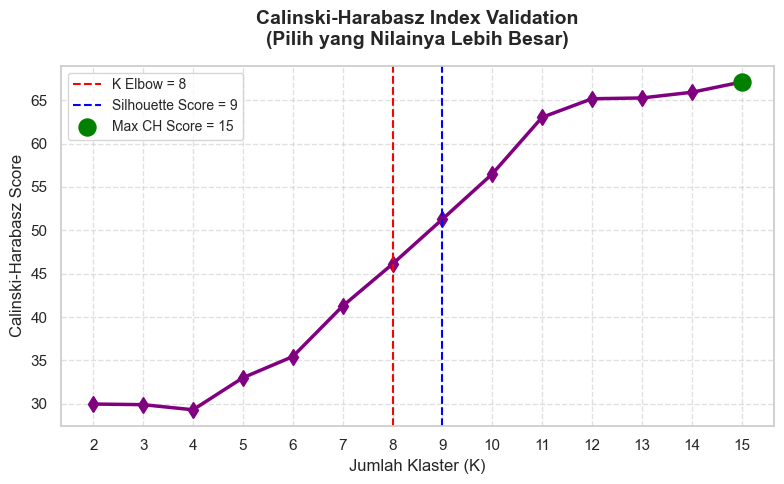

In [19]:
# ── 1. Hitung Evaluasi Eksternal (Mulai dari K=2) ──
K_range_eval = list(range(2, max_k + 1))
sil_scores = []
ch_scores = []
cluster_size_dist = {}

for k in K_range_eval:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    sil_scores.append(silhouette_score(X, labels))
    # Menggunakan metrik Calinski-Harabasz
    ch_scores.append(calinski_harabasz_score(X, labels))
    
    counts = pd.Series(labels).value_counts().sort_values(ascending=False)
    cluster_size_dist[k] = counts.tolist()

# ── 2. Penyusunan Tabel Ringkasan Evaluasi Lengkap ──
eval_data = []
# Masukkan K=1 secara manual karena K=1 tidak punya nilai Silhouette dan Calinski
eval_data.append({
    'K': 1, 
    'WCSS': round(wcss[0], 4), 
    'Silhouette': np.nan, 
    'Calinski': np.nan,
    'Distribusi_Ukuran': str([N])
})

for idx, k in enumerate(K_range_eval):
    sizes = cluster_size_dist[k]
    eval_data.append({
        'K': k,
        'WCSS': round(wcss[k - 1], 4),
        'Silhouette': round(sil_scores[idx], 4),
        'Calinski': round(ch_scores[idx], 4),
        'Distribusi_Ukuran': str(sizes)
    })

df_evaluasi_k = pd.DataFrame(eval_data)

print("=== TABEL EVALUASI METRIK VALIDASI ===")
display(df_evaluasi_k)

# ── 3. Dokumentasi File Eksternal ──
os.makedirs('data/4_Data_Clusterized/1_Klaster_Umum/1_Penentuan_Nilai_K', exist_ok=True)
# Mengubah nama file output agar sesuai dengan metrik yang digunakan
df_evaluasi_k.to_excel('data/4_Data_Clusterized/1_Klaster_Umum/1_Penentuan_Nilai_K/Evaluasi_Komprehensif_Calinski.xlsx', index=False)
# df_evaluasi_k.to_csv('data/4_Data_Clusterized/1_Klaster_Umum/1_Penentuan_Nilai_K/Evaluasi_Komprehensif_Calinski.csv', index=False)

# ── 4. Visualisasi Single Panel Metrik Validasi (Calinski) ──
k_opt_ch = K_range_eval[np.argmax(ch_scores)]

plt.figure(figsize=(8, 5))

# Plot Calinski-Harabasz Index
plt.plot(K_range_eval, ch_scores, 'd-', color='purple', linewidth=2.5, markersize=8)

# Garis acuan rekomendasi Elbow (Asumsi k_opt_elbow sudah ada dari Cell 7)
plt.axvline(x=k_opt_elbow, color='red', linestyle='--', label=f'K Elbow = {k_opt_elbow}')
plt.axvline(x=k_opt_sil, color='blue', linestyle='--', label=f'Silhouette Score = {k_opt_sil}')

# Sorotan nilai puncak Calinski
plt.scatter(k_opt_ch, max(ch_scores), color='green', s=150, zorder=5, label=f'Max CH Score = {k_opt_ch}')

plt.title('Calinski-Harabasz Index Validation\n(Pilih yang Nilainya Lebih Besar)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jumlah Klaster (K)', fontsize=12)
plt.ylabel('Calinski-Harabasz Score', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(K_range_eval)

plt.tight_layout()
plt.savefig('data/4_Data_Clusterized/Images/2_Validasi_Calinski.png', dpi=300, bbox_inches='tight')
plt.show()

Langkah Ke-9 Data Clustering Menggunakan K-Means

WEIGHTED K-Means Clustering Final dengan K = 9


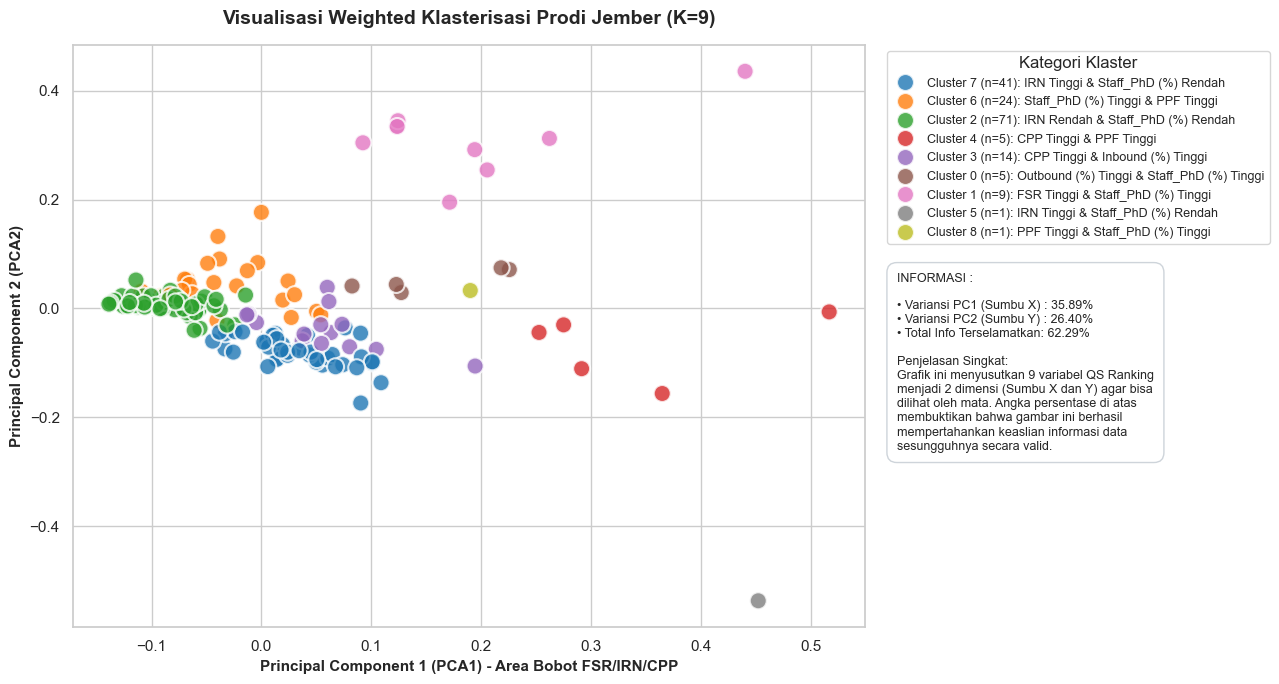

=== CLUSTER PROFILE (Rata-rata Z-score Asli per Cluster) ===


,Jumlah Prodi,FSR,IRN,CPP,PPF,Staff_PhD (%),IFR (%),PIS (%),Inbound (%),Outbound (%)
Cluster,,,,,,,,,,
0,5,0.942,0.494,0.920,1.150,1.679,-0.077,-0.189,-0.271,2.550
1,9,3.883,0.038,0.169,0.355,0.415,-0.077,-0.189,-0.271,-0.288
2,71,-0.332,-0.580,-0.491,-0.449,-0.569,-0.077,0.022,-0.066,-0.170
3,14,-0.327,-0.121,1.215,-0.167,-0.130,-0.077,-0.189,0.919,0.083
4,5,0.108,0.596,4.291,1.283,0.849,-0.077,-0.189,-0.183,-0.288
5,1,-0.359,9.093,-0.337,-0.245,-0.703,-0.077,0.126,-0.271,-0.288
6,24,0.039,-0.393,-0.410,0.463,1.679,-0.077,0.407,-0.271,-0.093
7,41,-0.325,0.886,0.014,-0.029,-0.376,0.243,-0.122,0.087,0.123
8,1,0.692,1.110,-0.148,9.204,1.679,-0.077,-0.189,-0.271,-0.288



=== KARAKTERISTIK MENONJOL PER CLUSTER (Total: 171 Program Studi) ===


,Jumlah Prodi,Variabel Tertinggi #1,Variabel Tertinggi #2,Variabel Terendah
Cluster,,,,
0,5,Outbound (%) (+2.550),Staff_PhD (%) (+1.679),Inbound (%) (-0.271)
1,9,FSR (+3.883),Staff_PhD (%) (+0.415),Outbound (%) (-0.288)
2,71,PIS (%) (+0.022),Inbound (%) (-0.066),IRN (-0.580)
3,14,CPP (+1.215),Inbound (%) (+0.919),FSR (-0.327)
4,5,CPP (+4.291),PPF (+1.283),Outbound (%) (-0.288)
5,1,IRN (+9.093),PIS (%) (+0.126),Staff_PhD (%) (-0.703)
6,24,Staff_PhD (%) (+1.679),PPF (+0.463),CPP (-0.410)
7,41,IRN (+0.886),IFR (%) (+0.243),Staff_PhD (%) (-0.376)
8,1,PPF (+9.204),Staff_PhD (%) (+1.679),Outbound (%) (-0.288)


**DITEMUKAN 2 CLUSTER DENGAN n≤2:**<br>Cluster ini terbentuk karena program studi memiliki nilai fitur (terutama pada bobot prioritas) yang sangat ekstrem atau <i>outlier</i>

,Cluster,Program Studi,FSR,IRN,CPP,PPF,Staff_PhD (%),IFR (%),PIS (%),Inbound (%),Outbound (%)
48,5,UNEJ - Kesehatan Masyarakat,-0.359052,9.092892,-0.337193,-0.244534,-0.702645,-0.076696,0.126484,-0.270939,-0.288381
105,8,UNEJ - Pendidikan Matematika (S3),0.691879,1.110098,-0.147969,9.204399,1.679258,-0.076696,-0.189148,-0.270939,-0.288381


<br>**Keterangan:**<br>- **Cluster 5** (UNEJ - Kesehatan Masyarakat) : Karena variabel IRN yang tinggi dan variabel Staff_PhD (%) yang rendah.<br>- **Cluster 8** (UNEJ - Pendidikan Matematika (S3)) : Karena variabel PPF yang tinggi dan variabel Staff_PhD (%) yang tinggi.

In [20]:
# ============================================================
# CELL 9: EKSEKUSI FINAL WEIGHTED K-MEANS & PROFILING 
# ============================================================

# Styling visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# ══════════════════════════════════════════════════════════════
# 📝 INPUT USER: TENTUKAN NILAI K FINAL DI SINI
# ══════════════════════════════════════════════════════════════
K_Pilihan_Bejo = 9
FINAL_K = K_Pilihan_Bejo

# ── 0. Load Data & Persiapan Folder ──
df = pd.read_excel('data/3_Data_Normalized/Hasil_ZScore_Data_Normalization.xlsx')
kolom_qs = ['FSR', 'IRN', 'CPP', 'PPF', 'Staff_PhD (%)',
            'IFR (%)', 'PIS (%)', 'Inbound (%)', 'Outbound (%)']
X = df[kolom_qs].values

output_dir_excel = 'data/4_Data_Clusterized/1_Klaster_Umum/2_Hasil_Klasterisasi/'
output_dir_images = 'data/4_Data_Clusterized/Images/'
os.makedirs(output_dir_excel, exist_ok=True)
os.makedirs(output_dir_images, exist_ok=True)

# FEATURE WEIGHTING
qs_weights = {
    'FSR': 0.10, 'IRN': 0.10, 'CPP': 0.10, 'PPF': 0.05, 'Staff_PhD (%)': 0.05,
    'IFR (%)': 0.025, 'PIS (%)': 0.025, 'Inbound (%)': 0.025, 'Outbound (%)': 0.025
}
weights_array = np.array([qs_weights[col] for col in kolom_qs])
X_weighted = X * weights_array 

# ============================================================
# ⚙️ FASE KOMPUTASI (Menghitung semua data di belakang layar)
# ============================================================

# 1. K-Means
kmeans = KMeans(n_clusters=FINAL_K, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_weighted)
cluster_counts = df['Cluster'].value_counts().sort_index()

# 2. Cluster Profiling
cluster_profile = df.groupby('Cluster')[kolom_qs].mean()
cluster_profile.insert(0, 'Jumlah Prodi', cluster_counts)

# 3. Karakteristik & Auto Labels
data_karakteristik = []
auto_labels = {}

for c in cluster_profile.index:
    profile_c = cluster_profile.loc[c, kolom_qs]
    n_prodi = cluster_counts[c]
    
    # --- A. Logika Baru untuk Tabel Karakteristik (Tertinggi dan Terendah) ---
    # Mengurutkan dari nilai yang paling positif ke paling negatif
    sorted_profile = profile_c.sort_values(ascending=False)
    
    var_tinggi_1 = sorted_profile.index[0]
    val_tinggi_1 = sorted_profile.iloc[0]
    
    var_tinggi_2 = sorted_profile.index[1]
    val_tinggi_2 = sorted_profile.iloc[1]
    
    var_rendah = sorted_profile.index[-1] # Index -1 mengambil nilai paling bawah (terkecil/minus terdalam)
    val_rendah = sorted_profile.iloc[-1]
    
    data_karakteristik.append({
        'Cluster': c,
        'Jumlah Prodi': n_prodi,
        'Variabel Tertinggi #1': f"{var_tinggi_1} ({val_tinggi_1:+.3f})",
        'Variabel Tertinggi #2': f"{var_tinggi_2} ({val_tinggi_2:+.3f})",
        'Variabel Terendah': f"{var_rendah} ({val_rendah:+.3f})"
    })
    
    # --- B. Logika Lama untuk Label Legend PCA (Tetap dipertahankan agar grafik tidak rusak) ---
    top2_abs = profile_c.abs().sort_values(ascending=False).head(2)
    desc_parts_label = [] 
    for var in top2_abs.index:
        val = profile_c[var]
        arah = "Tinggi" if val > 0 else "Rendah"
        desc_parts_label.append(f"{var} {arah}")
    
    auto_labels[c] = f"Cluster {c} (n={n_prodi}): " + " & ".join(desc_parts_label)

# Membuat DataFrame dari list karakteristik
df_karakteristik = pd.DataFrame(data_karakteristik)
# Menghilangkan index bawaan (0,1,2..) dan menggunakan kolom Cluster sebagai index baris
df_karakteristik.set_index('Cluster', inplace=True)

# 4. PCA Setup
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_weighted)
var_explained = pca.explained_variance_ratio_
total_var = sum(var_explained) * 100

df_plot = df.copy()
df_plot['PCA1'] = X_pca[:, 0]
df_plot['PCA2'] = X_pca[:, 1]
df_plot['Label Klaster'] = df_plot['Cluster'].map(auto_labels)

# 5. Diagnostik Outlier (n<=2)
small_clusters = cluster_counts[cluster_counts <= 2]

# 6. Menyimpan File Excel (Silently)
profile_output = f"{output_dir_excel}Cluster_Profile_Weighted_K-{FINAL_K}.xlsx"
output_file = f"{output_dir_excel}Hasil_Klasterisasi_Weighted_KMeans_K-{FINAL_K}.xlsx"
cluster_profile.to_excel(profile_output)
df.to_excel(output_file, index=False)


# ============================================================
# 📺 FASE DISPLAY (Menampilkan output sesuai urutan request)
# ============================================================

# --- Urutan 1: Teks Awal ---
print(f"WEIGHTED K-Means Clustering Final dengan K = {FINAL_K}")

# --- Urutan 2: Visualisasi Scatter Plot ---
fig, ax = plt.subplots(figsize=(13, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='Label Klaster', palette='tab10', data=df_plot, s=150, alpha=0.8, edgecolor='white', linewidth=1.5, ax=ax)

ax.set_title(f'Visualisasi Weighted Klasterisasi Prodi Jember (K={FINAL_K})', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Principal Component 1 (PCA1) - Area Bobot FSR/IRN/CPP', fontsize=11, fontweight='bold')
ax.set_ylabel('Principal Component 2 (PCA2)', fontsize=11, fontweight='bold')
ax.legend(title='Kategori Klaster', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

info_text = (
    "INFORMASI :\n\n"
    f"• Variansi PC1 (Sumbu X) : {var_explained[0]*100:.2f}%\n"
    f"• Variansi PC2 (Sumbu Y) : {var_explained[1]*100:.2f}%\n"
    f"• Total Info Terselamatkan: {total_var:.2f}%\n\n"
    "Penjelasan Singkat:\n"
    "Grafik ini menyusutkan 9 variabel QS Ranking\n"
    "menjadi 2 dimensi (Sumbu X dan Y) agar bisa\n"
    "dilihat oleh mata. Angka persentase di atas\n"
    "membuktikan bahwa gambar ini berhasil\n"
    "mempertahankan keaslian informasi data\n"
    "sesungguhnya secara valid."
)
ax.text(1.04, 0.3, info_text, transform=ax.transAxes, fontsize=9, verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.8', facecolor='white', edgecolor='#ced4da', alpha=1))
plt.tight_layout()

scatter_output_file = f"{output_dir_images}3_Visualisasi_Weighted_KMeans_K-{FINAL_K}.png"
plt.savefig(scatter_output_file, dpi=300, bbox_inches='tight')
plt.show() # Plot ditampilkan di sini

# --- Urutan 3 & 4: Tabel Cluster Profile ---
print("=== CLUSTER PROFILE (Rata-rata Z-score Asli per Cluster) ===")
display(cluster_profile.round(3))

# --- Urutan 5 & 6: Daftar Karakteristik Markdown ---
print(f"\n=== KARAKTERISTIK MENONJOL PER CLUSTER (Total: {cluster_counts.sum()} Program Studi) ===")
display(df_karakteristik)

# --- Urutan 7, 8, 9: Diagnostik Cluster Terisolasi ---
print("\n") # Memberi sedikit jarak
if len(small_clusters) > 0:
    teks_atas = f"**DITEMUKAN {len(small_clusters)} CLUSTER DENGAN n≤2:**<br>" \
                f"Cluster ini terbentuk karena program studi memiliki nilai fitur " \
                f"(terutama pada bobot prioritas) yang sangat ekstrem atau <i>outlier</i>"
    display(Markdown(teks_atas))

    anggota_terisolasi = df[df['Cluster'].isin(small_clusters.index)][['Cluster', 'Program Studi'] + kolom_qs]
    display(anggota_terisolasi)

    keterangan_list = ["<br>**Keterangan:**"]
    for _, row in anggota_terisolasi.iterrows():
        z_vals = row[kolom_qs].astype(float)
        top2   = z_vals.abs().sort_values(ascending=False).head(2)
        parts  = []
        for var in top2.index:
            arah = "tinggi" if z_vals[var] > 0 else "rendah"
            parts.append(f"variabel {var} yang {arah}")
        
        keterangan_list.append(f"- **Cluster {row['Cluster']}** ({row['Program Studi']}) : Karena {' dan '.join(parts)}.")

    display(Markdown("<br>".join(keterangan_list)))
else:
    display(Markdown("**✅ Tidak ada cluster dengan anggota ≤2.**"))

=== KOMPOSISI VARIABEL PADA PC1 DAN PC2 (PCA Loadings) ===


,PC1 (Sumbu X),PC2 (Sumbu Y)
FSR,0.4462,0.8031
IRN,0.5479,-0.5572
CPP,0.6607,-0.1284
PPF,0.2103,0.0523
Staff_PhD (%),0.1380,0.1549
IFR (%),0.0105,-0.0200
PIS (%),-0.0142,0.0013
Inbound (%),0.0053,-0.0305
Outbound (%),0.0259,-0.0069


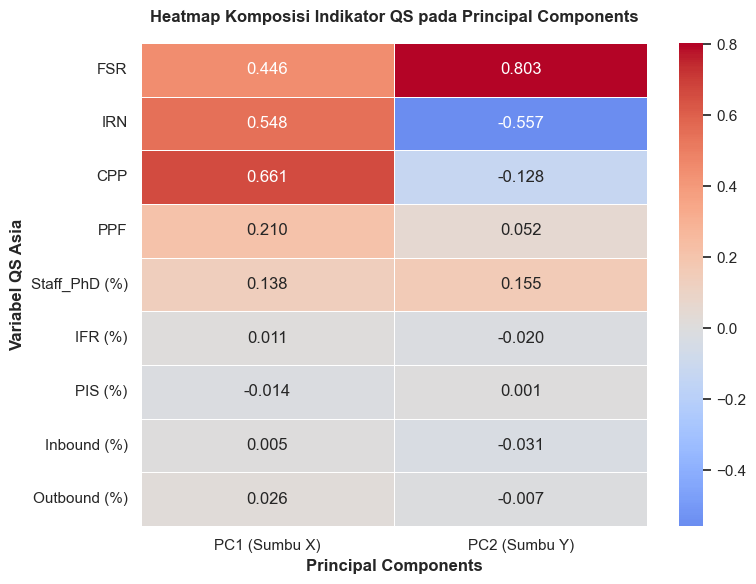

In [22]:
komposisi_pca = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1 (Sumbu X)', 'PC2 (Sumbu Y)'], 
    index=kolom_qs
)

print("=== KOMPOSISI VARIABEL PADA PC1 DAN PC2 (PCA Loadings) ===")
display(komposisi_pca.round(4))

# Visualisasi Heatmap agar lebih mudah dibaca untuk lampiran skripsi
plt.figure(figsize=(8, 6))
sns.heatmap(komposisi_pca, annot=True, cmap='coolwarm', center=0, fmt='.3f', linewidths=0.5)
plt.title('Heatmap Komposisi Indikator QS pada Principal Components', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Variabel QS Asia', fontweight='bold')
plt.xlabel('Principal Components', fontweight='bold')
plt.tight_layout()
plt.savefig('data/4_Data_Clusterized/Images/4_Heatmap_Komponen_PCA.png', dpi=300, bbox_inches='tight')
plt.show()

Opsional Klasterisasi berdasarkan 2 variabel


PROSES: KLASTER STUDENT EXCHANGE
-> K Optimal Terdeteksi (Elbow) : 3
-> Silhouette Score (K=3)  : 0.9020

Distribusi Anggota Klaster:
Cluster
0    151
1      9
2     11

Saved Hasil  : data/4_Data_Clusterized/2_Klaster_Student_Exchange\Hasil_Klasterisasi_Student_Exchange_K3.xlsx
Saved Profile: data/4_Data_Clusterized/2_Klaster_Student_Exchange\Profile_Klaster_Student_Exchange_K3.xlsx

PROSES: KLASTER INTERNATIONALITY READINESS


C:\Users\satri\AppData\Local\Temp\ipykernel_21060\521947472.py:25: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
C:\Users\satri\AppData\Local\Temp\ipykernel_21060\521947472.py:25: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)


-> K Optimal Terdeteksi (Elbow) : 3
-> Silhouette Score (K=3)  : 0.9620

Distribusi Anggota Klaster:
Cluster
0    167
1      1
2      3

Saved Hasil  : data/4_Data_Clusterized/3_Klaster_Internationality_Readiness\Hasil_Klasterisasi_Internationality_Readiness_K3.xlsx
Saved Profile: data/4_Data_Clusterized/3_Klaster_Internationality_Readiness\Profile_Klaster_Internationality_Readiness_K3.xlsx

PROSES: KLASTER RESEARCH PERFORMANCE


C:\Users\satri\AppData\Local\Temp\ipykernel_21060\521947472.py:25: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)


-> K Optimal Terdeteksi (Elbow) : 4
-> Silhouette Score (K=4)  : 0.4980

Distribusi Anggota Klaster:
Cluster
0    122
1      5
2     43
3      1

Saved Hasil  : data/4_Data_Clusterized/4_Klaster_Research_Performance\Hasil_Klasterisasi_Research_Performance_K4.xlsx
Saved Profile: data/4_Data_Clusterized/4_Klaster_Research_Performance\Profile_Klaster_Research_Performance_K4.xlsx

Grafik Gabungan Utama disimpan di : data/4_Data_Clusterized/Images/5_Visualisasi_Gabungan_Bivariat.png


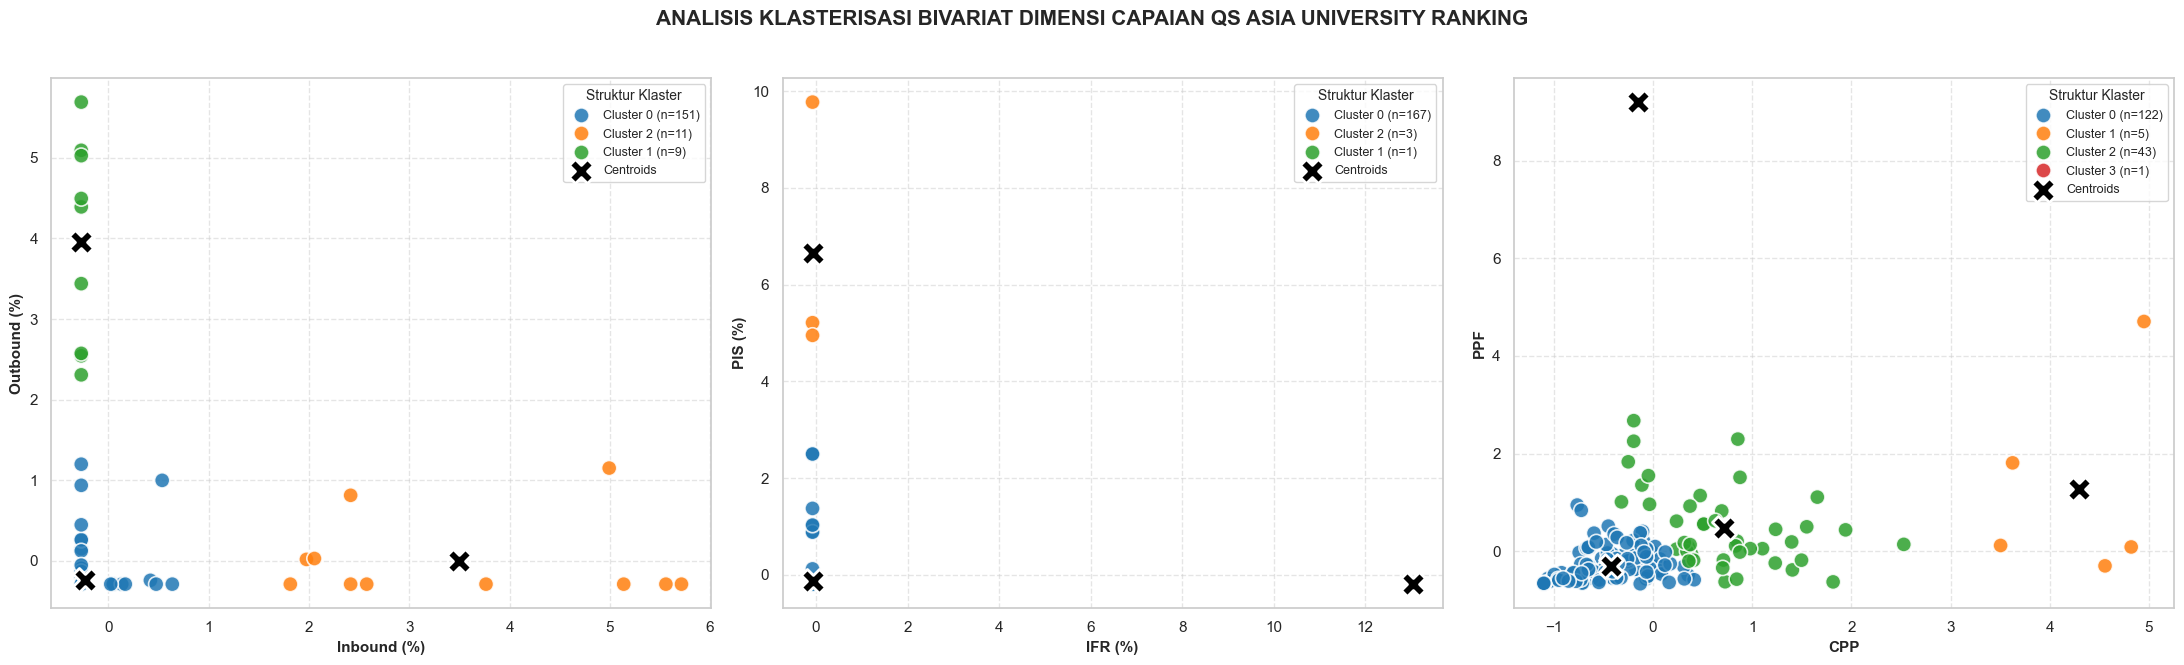

In [23]:
# ── SEABORN & MATPLOTLIP SETTING ──
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# ── 0. LOAD DATA SOURCE ──
# Menyesuaikan dengan path dataset normalized Anda
path_source = 'data/3_Data_Normalized/Hasil_ZScore_Data_Normalization.xlsx'
df_normalized = pd.read_excel(path_source)

# ── 1. FUNGSI OTOMATISASI ELBOW DETECTOR (Perpendicular Distance) ──
def find_optimal_k_elbow(k_values, inertia_values):
    k_arr = np.array(k_values, dtype=float)
    i_arr = np.array(inertia_values, dtype=float)
    
    # Normalisasi ke skala 0-1 agar adil secara geometri
    k_norm = (k_arr - k_arr.min()) / (k_arr.max() - k_arr.min())
    i_norm = (i_arr - i_arr.min()) / (i_arr.max() - i_arr.min())
    
    p1 = np.array([k_norm[0], i_norm[0]])
    p2 = np.array([k_norm[-1], i_norm[-1]])
    
    distances = []
    for i in range(len(k_norm)):
        p = np.array([k_norm[i], i_norm[i]])
        d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distances.append(d)
    return k_values[np.argmax(distances)]

# ── 2. DEFINISI CONFIGURASI 3 KOMBINASI KLASTER ──
klaster_configs = {
    'Student_Exchange': {
        'nama': 'Klaster Student Exchange',
        'vars': ['Inbound (%)', 'Outbound (%)'],
        'folder': 'data/4_Data_Clusterized/2_Klaster_Student_Exchange'
    },
    'Internationality_Readiness': {
        'nama': 'Klaster Internationality Readiness',
        'vars': ['IFR (%)', 'PIS (%)'],
        'folder': 'data/4_Data_Clusterized/3_Klaster_Internationality_Readiness'
    },
    'Research_Performance': {
        'nama': 'Klaster Research Performance',
        'vars': ['CPP', 'PPF'],
        'folder': 'data/4_Data_Clusterized/4_Klaster_Research_Performance'
    }
}

# SETUP GRAFIK BERSAMAAN (1 Baris, 3 Kolom)
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5))
max_k_search = 10
k_range = list(range(1, max_k_search + 1))

# ── 3. LOOPING EKSEKUSI UNTUK SETIAP KOMBINASI ──
for idx, (key, config) in enumerate(klaster_configs.items()):
    print(f"\n=======================================================")
    print(f"PROSES: {config['nama'].upper()}")
    print(f"=======================================================")
    
    # Buat direktori jika belum ada
    os.makedirs(config['folder'], exist_ok=True)
    
    # Ambil matriks fitur (hanya 2 variabel)
    X_sub = df_normalized[config['vars']].values
    
    # Pencarian K Optimal
    wcss = []
    sil_scores = []
    for k in k_range:
        kmeans_test = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        labels_test = kmeans_test.fit_predict(X_sub)
        wcss.append(kmeans_test.inertia_)
        if k >= 2:
            sil_scores.append(silhouette_score(X_sub, labels_test))
            
    # Tentukan K Final menggunakan geometri Elbow
    k_final = find_optimal_k_elbow(k_range, wcss)
    sil_final = silhouette_score(X_sub, KMeans(n_clusters=k_final, init='k-means++', random_state=42, n_init=10).fit_predict(X_sub))
    # dbi_final = davies_bouldin_score(X_sub, KMeans(n_clusters=k_final, init='k-means++', random_state=42, n_init=10).fit_predict(X_sub))
    
    print(f"-> K Optimal Terdeteksi (Elbow) : {k_final}")
    print(f"-> Silhouette Score (K={k_final})  : {sil_final:.4f}")
    # print(f"-> Davies-Bouldin Index (K={k_final}): {dbi_final:.4f}")
    
    # Eksekusi Final K-Means
    kmeans_final = KMeans(n_clusters=k_final, init='k-means++', random_state=42, n_init=10)
    df_result = df_normalized.copy()
    df_result['Cluster'] = kmeans_final.fit_predict(X_sub)
    
    # Distribusi Anggota
    counts = df_result['Cluster'].value_counts().sort_index()
    print("\nDistribusi Anggota Klaster:")
    print(counts.to_string())
    
    # Pembuatan Cluster Profile (Rata-rata Z-Score)
    profile = df_result.groupby('Cluster')[config['vars']].mean()
    profile.insert(0, 'Jumlah Prodi', counts)
    
    # SIMPAN OUTPUT KE EXCEL
    file_hasil = os.path.join(config['folder'], f"Hasil_Klasterisasi_{key}_K{k_final}.xlsx")
    file_profile = os.path.join(config['folder'], f"Profile_Klaster_{key}_K{k_final}.xlsx")
    
    df_result.to_excel(file_hasil, index=False)
    profile.to_excel(file_profile)
    print(f"\nSaved Hasil  : {file_hasil}")
    print(f"Saved Profile: {file_profile}")
    
    # PLOT KE SUBPLOT (GRAFIK BERSAMAAN)
    ax = axes[idx]
    # Membuat label klaster dinamis untuk legenda plot
    df_result['Label_Legenda'] = df_result['Cluster'].apply(lambda c: f"Cluster {c} (n={counts[c]})")
    
    sns.scatterplot(
        x=config['vars'][0], 
        y=config['vars'][1], 
        hue='Label_Legenda',
        palette='tab10', 
        data=df_result, 
        s=120, 
        alpha=0.85, 
        edgecolor='white', 
        linewidth=1.2,
        ax=ax
    )
    
    # Plot Centroid
    centroids = kmeans_final.cluster_centers_
    ax.scatter(
        centroids[:, 0], centroids[:, 1], 
        s=300, c='black', marker='X', edgecolor='white', linewidth=2, 
        label='Centroids'
    )
    
    # ax.set_title(f"{config['nama']} (K={k_final})\nSil: {sil_final:.3f} | DBI: {dbi_final:.3f}", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(config['vars'][0], fontsize=11, fontweight='semibold')
    ax.set_ylabel(config['vars'][1], fontsize=11, fontweight='semibold')
    ax.legend(title="Struktur Klaster", loc='upper right', fontsize=9, title_fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

# Finalisasi tata letak seluruh grafik panel
plt.suptitle('ANALISIS KLASTERISASI BIVARIAT DIMENSI CAPAIAN QS ASIA UNIVERSITY RANKING', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

# Simpan grafik gabungan utama
main_plot_path = r'data/4_Data_Clusterized/Images/5_Visualisasi_Gabungan_Bivariat.png'
plt.savefig(main_plot_path, dpi=300, bbox_inches='tight')
print(f"\n=======================================================")
print(f"Grafik Gabungan Utama disimpan di : {main_plot_path}")
print(f"=======================================================")
plt.show()